# Unsupervised clustering to potentially identify phenotypes within dataset

### Objectives 
- Perform K-Means and LCA on dataset
- Visualize different groups
- Do the same but just on the PCOS diagnosed group

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"PCOS distribution:\n{df['pcos_y_n'].value_counts()}\n")

# Define features for clustering
numerical_cols = ['age_yrs', 'weight_kg', 'heightcm', 'bmi', 'pulse_ratebpm', 'rr_breaths_min',
                  'hbg_dl', 'cycle_lengthdays', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh',
                  'hipinch', 'waistinch', 'waist_hip_ratio', 'tsh_miu_l', 'amhng_ml',
                  'prlng_ml', 'vit_d3_ng_ml', 'prgng_ml', 'rbsmg_dl', 'bp_systolic_mmhg',
                  'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r',
                  'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']

# Prepare data
X = df[numerical_cols].fillna(df[numerical_cols].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features selected: {len(numerical_cols)}")
print(df[numerical_cols].head())

Dataset shape: (541, 44)
PCOS distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64

Features selected: 27
   age_yrs  weight_kg  heightcm        bmi  pulse_ratebpm  rr_breaths_min  \
0     28.0       44.6     152.0  19.304017           78.0            22.0   
1     36.0       65.0     161.5  24.921163           74.0            20.0   
2     33.0       68.8     165.0  25.270891           72.0            18.0   
3     37.0       65.0     148.0  29.674945           72.0            20.0   
4     25.0       52.0     161.0  20.060954           72.0            18.0   

   hbg_dl  cycle_lengthdays  fsh_miu_ml  lh_miu_ml  ...  vit_d3_ng_ml  \
0   10.48               5.0        7.95       3.68  ...          17.1   
1   11.70               5.0        6.73       1.09  ...          61.3   
2   11.80               5.0        5.54       0.88  ...          49.7   
3   12.00               5.0        8.06       2.36  ...          33.4   
4   10.00               5.0        3.98       0.90  

## 1. Optimal K-Means Clustering (Full Dataset)

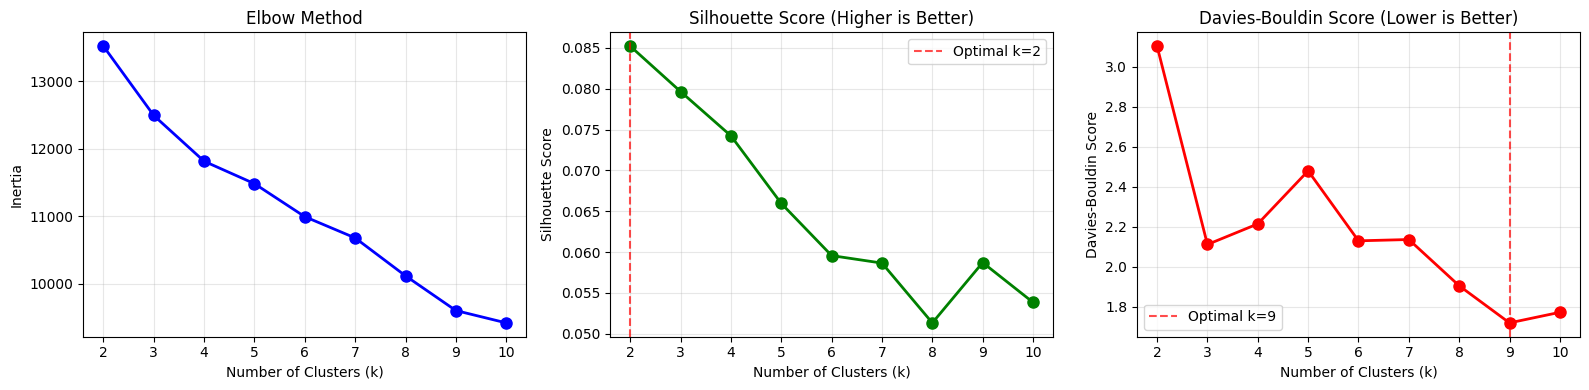

Optimal k (Silhouette): 2
Optimal k (Davies-Bouldin): 9

Silhouette scores: ['0.085', '0.080', '0.074', '0.066', '0.060', '0.059', '0.051', '0.059', '0.054']
Davies-Bouldin scores: ['3.104', '2.111', '2.214', '2.480', '2.130', '2.136', '1.905', '1.719', '1.772']


In [3]:
# Determine optimal number of clusters using elbow method and silhouette score
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(True, alpha=0.3)
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_silhouette}')
axes[1].legend()

# Davies-Bouldin score (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].grid(True, alpha=0.3)
optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]
axes[2].axvline(x=optimal_k_db, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_db}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Optimal k (Silhouette): {optimal_k_silhouette}")
print(f"Optimal k (Davies-Bouldin): {optimal_k_db}")
print(f"\nSilhouette scores: {[f'{s:.3f}' for s in silhouette_scores]}")
print(f"Davies-Bouldin scores: {[f'{s:.3f}' for s in davies_bouldin_scores]}")


 K-Means Applied with k=2
Cluster distribution:
0    251
1    290
Name: count, dtype: int64



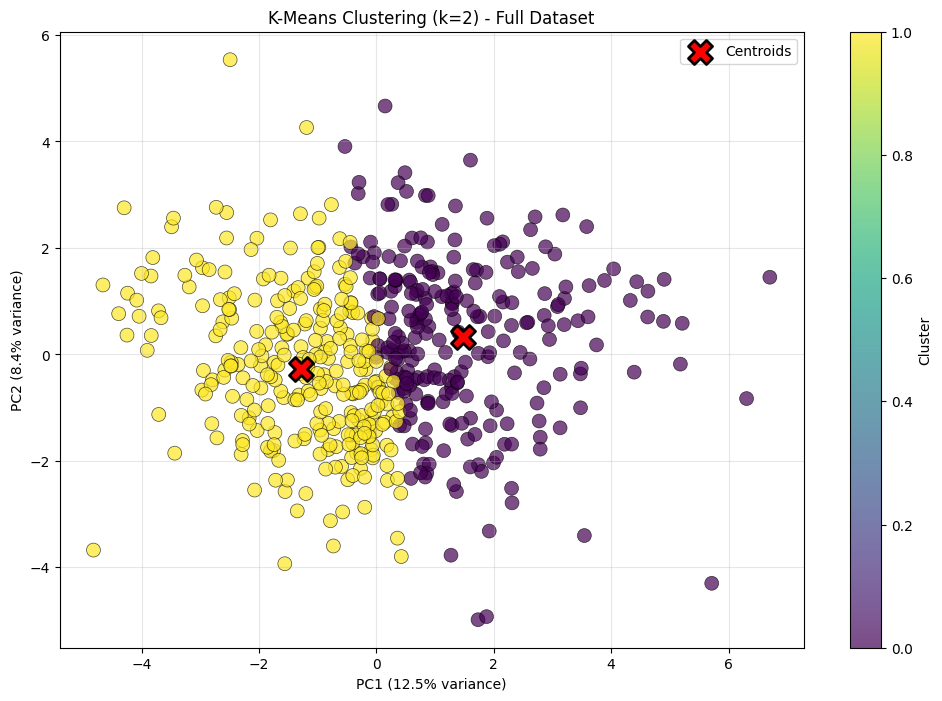

Cluster Characteristics (Full Dataset):

Cluster 0 (n=251, PCOS rate=52.2%):
follicle_no_r     8.629482
follicle_no_l     8.023904
amhng_ml          6.275936
bmi              26.865432
weight_kg        67.190837

Cluster 1 (n=290, PCOS rate=15.9%):
follicle_no_r     4.920690
follicle_no_l     4.489655
amhng_ml          5.053459
bmi              22.115691
weight_kg        53.099310


In [4]:
# Apply optimal K-Means clustering (use k=2 as compromise)
optimal_k = 2
kmeans_full = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_full = kmeans_full.fit_predict(X_scaled)

df['Cluster_Full'] = clusters_full

print(f"\n K-Means Applied with k={optimal_k}")
print(f"Cluster distribution:\n{pd.Series(clusters_full).value_counts().sort_index()}\n")

# Visualize using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_full, cmap='viridis', 
                     alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
plt.scatter(pca.transform(kmeans_full.cluster_centers_)[:, 0], 
           pca.transform(kmeans_full.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'K-Means Clustering (k={optimal_k}) - Full Dataset')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cluster characteristics
print("Cluster Characteristics (Full Dataset):")
print("=" * 80)
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster_Full'] == cluster][numerical_cols]
    pcos_ratio = df[df['Cluster_Full'] == cluster]['pcos_y_n'].mean()
    print(f"\nCluster {cluster} (n={len(cluster_data)}, PCOS rate={pcos_ratio:.1%}):")
    print(cluster_data.mean()[['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'bmi', 'weight_kg']].to_string())

## 2. K-Means Clustering on PCOS-Diagnosed Group Only

PCOS-Only Dataset: 177 patients


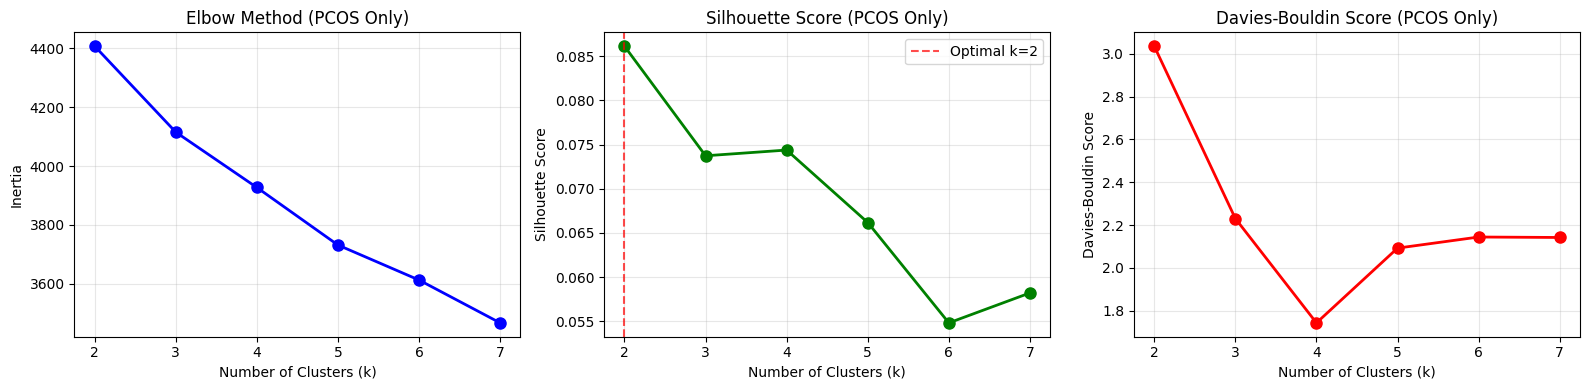

Optimal k for PCOS group (Silhouette): 2

✅ K-Means Applied to PCOS Group with k=2
Phenotype distribution:
0     59
1    118
Name: count, dtype: int64



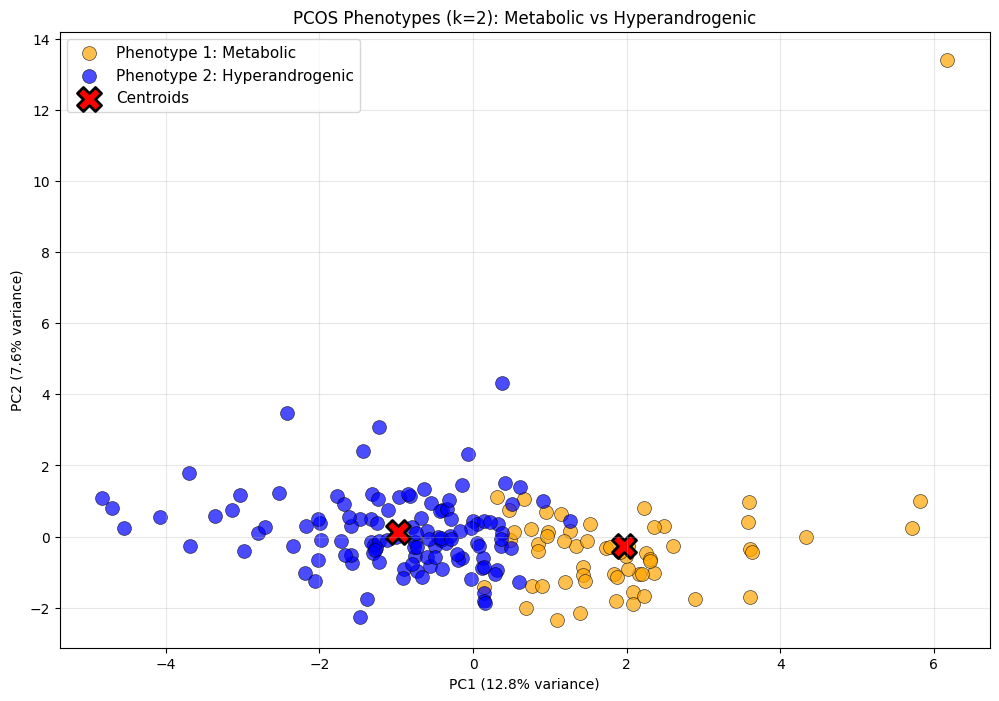

PCOS Phenotype Characteristics:

Phenotype 1: Metabolic (n=59):
follicle_no_r    10.576271
follicle_no_l    10.881356
amhng_ml          7.790000
bmi              29.129794
weight_kg        75.835593
lh_miu_ml         3.007458
fsh_miu_ml        5.552203

Phenotype 2: Hyperandrogenic (n=118):
follicle_no_r    10.855932
follicle_no_l     9.237288
amhng_ml          7.871949
bmi              23.656779
weight_kg        56.561017
lh_miu_ml        20.099763
fsh_miu_ml        4.985788

-------------------------------Phenotype Mapping:-------------------------------
Phenotype 0: Metabolic (Blue)
Phenotype 1: Hyperandrogenic (Orange)


In [ ]:
# Subset to PCOS-positive patients only
df_pcos = df[df['pcos_y_n'] == 1].reset_index(drop=True)
X_pcos = df_pcos[numerical_cols].fillna(df_pcos[numerical_cols].mean())
X_pcos_scaled = scaler.fit_transform(X_pcos)

print(f"PCOS-Only Dataset: {len(df_pcos)} patients")

# Determine optimal clusters for PCOS group
inertias_pcos = []
silhouette_scores_pcos = []
davies_bouldin_scores_pcos = []
K_range_pcos = range(2, 8)

for k in K_range_pcos:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pcos_scaled)
    inertias_pcos.append(kmeans.inertia_)
    silhouette_scores_pcos.append(silhouette_score(X_pcos_scaled, kmeans.labels_))
    davies_bouldin_scores_pcos.append(davies_bouldin_score(X_pcos_scaled, kmeans.labels_))

# Plot metrics for PCOS group
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_range_pcos, inertias_pcos, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (PCOS Only)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range_pcos, silhouette_scores_pcos, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (PCOS Only)')
axes[1].grid(True, alpha=0.3)
optimal_k_pcos_silhouette = K_range_pcos[np.argmax(silhouette_scores_pcos)]
axes[1].axvline(x=optimal_k_pcos_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_pcos_silhouette}')
axes[1].legend()

axes[2].plot(K_range_pcos, davies_bouldin_scores_pcos, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (PCOS Only)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal k for PCOS group (Silhouette): {optimal_k_pcos_silhouette}")

# Apply optimal K-Means to PCOS group (use k=2 or k=3)
optimal_k_pcos = 2
kmeans_pcos = KMeans(n_clusters=optimal_k_pcos, random_state=42, n_init=10)
clusters_pcos = kmeans_pcos.fit_predict(X_pcos_scaled)

df_pcos['Cluster_PCOS'] = clusters_pcos

print(f"\n✅ K-Means Applied to PCOS Group with k={optimal_k_pcos}")
print(f"Phenotype distribution:\n{pd.Series(clusters_pcos).value_counts().sort_index()}\n")

# Identify phenotypes: Metabolic vs Hyperandrogenic
# Metabolic phenotype: high BMI, weight (metabolic dysfunction)
# Hyperandrogenic phenotype: high androgens, hair growth, skin issues
metabolic_score = []
for phenotype in range(optimal_k_pcos):
    phen_data = df_pcos[df_pcos['Cluster_PCOS'] == phenotype]
    # Score based on metabolic features (BMI, weight)
    metabolic_features = ['bmi', 'weight_kg']
    available_metabolic = [f for f in metabolic_features if f in numerical_cols]
    
    # Score based on androgenic features (hair growth, skin darkening, pimples)
    androgenic_features = ['hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n']
    available_androgenic = [f for f in androgenic_features if f in numerical_cols]
    
    metabolic_avg = phen_data[available_metabolic].mean().mean() if available_metabolic else 0
    androgenic_avg = phen_data[available_androgenic].mean().mean() if available_androgenic else 0
    
    metabolic_score.append(metabolic_avg)

# Assign phenotype labels
phenotype_labels = {}
metabolic_phenotype = np.argmax(metabolic_score)
hyperandrogenic_phenotype = 1 - metabolic_phenotype

phenotype_labels[metabolic_phenotype] = "Metabolic"
phenotype_labels[hyperandrogenic_phenotype] = "Hyperandrogenic"

# Map cluster to phenotype name
phenotype_names = [phenotype_labels[i] for i in range(optimal_k_pcos)]

# Visualize PCOS clusters using PCA with custom colors and labels
pca_pcos = PCA(n_components=2)
X_pcos_pca = pca_pcos.fit_transform(X_pcos_scaled)

# Define color mapping: Phenotype 1 (Metabolic) = Blue, Phenotype 2 (Hyperandrogenic) = Orange
colors = np.array(['orange', 'blue'])
cluster_colors = colors[clusters_pcos]
phenotype_cluster_colors = colors[np.array([metabolic_phenotype, hyperandrogenic_phenotype])]

plt.figure(figsize=(12, 8))
# Plot each cluster separately for proper labeling
for phenotype in range(optimal_k_pcos):
    mask = clusters_pcos == phenotype
    plt.scatter(X_pcos_pca[mask, 0], X_pcos_pca[mask, 1], 
               c=colors[phenotype], alpha=0.7, s=100, edgecolors='black', linewidth=0.5,
               label=f'Phenotype {phenotype + 1}: {phenotype_names[phenotype]}')

# Plot centroids
centroids_pca = pca_pcos.transform(kmeans_pcos.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')

plt.xlabel(f'PC1 ({pca_pcos.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_pcos.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'PCOS Phenotypes (k={optimal_k_pcos}): Metabolic vs Hyperandrogenic')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Phenotype characteristics
print("PCOS Phenotype Characteristics:")
print("=" * 80)
key_features = ['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'bmi', 'weight_kg', 'lh_miu_ml', 'fsh_miu_ml']
for phenotype in range(optimal_k_pcos):
    phenotype_data = df_pcos[df_pcos['Cluster_PCOS'] == phenotype][numerical_cols]
    print(f"\nPhenotype {phenotype + 1}: {phenotype_names[phenotype]} (n={len(phenotype_data)}):")
    features_available = [f for f in key_features if f in numerical_cols]
    print(phenotype_data.mean()[features_available].to_string())

# Store phenotype mapping for later use
phenotype_mapping = {
    'metabolic_phenotype': metabolic_phenotype,
    'hyperandrogenic_phenotype': hyperandrogenic_phenotype,
    'phenotype_labels': phenotype_labels
}
print(f"\n{'Phenotype Mapping:':-^80}")
print(f"Phenotype {metabolic_phenotype}: Metabolic (Blue)")
print(f"Phenotype {hyperandrogenic_phenotype}: Hyperandrogenic (Orange)")

## 3. Phenotype Comparison & Summary


Detailed PCOS Phenotype Profiles:

-----------------------------------PHENOTYPE 1 - Metabolic (Blue)-----------------------------------
Sample size: 59 patients
  follicle_no_r       :    10.58 ±   3.92  (  -1.7% vs PCOS avg)
  follicle_no_l       :    10.88 ±   4.80  ( +11.2% vs PCOS avg)
  amhng_ml            :     7.79 ±   6.49  (  -0.7% vs PCOS avg)
  fsh_lh              :     8.88 ±  42.33  ( +67.2% vs PCOS avg)
  bmi                 :    29.13 ±   3.82  ( +14.3% vs PCOS avg)
  weight_kg           :    75.84 ±   9.11  ( +20.4% vs PCOS avg)
  hair_growth_y_n     :     0.56 ±   0.50  (  -2.0% vs PCOS avg)
  skin_darkening_y_n  :     0.68 ±   0.47  (  +9.1% vs PCOS avg)
  pimples_y_n         :     0.75 ±   0.44  (  +7.3% vs PCOS avg)
  cycle_r_i           :     0.63 ±   0.49  ( +18.1% vs PCOS avg)

-------------------------------PHENOTYPE 2 - Hyperandrogenic (Orange)-------------------------------
Sample size: 118 patients
  follicle_no_r       :    10.86 ±   4.30  (  +0.9% vs PCOS 

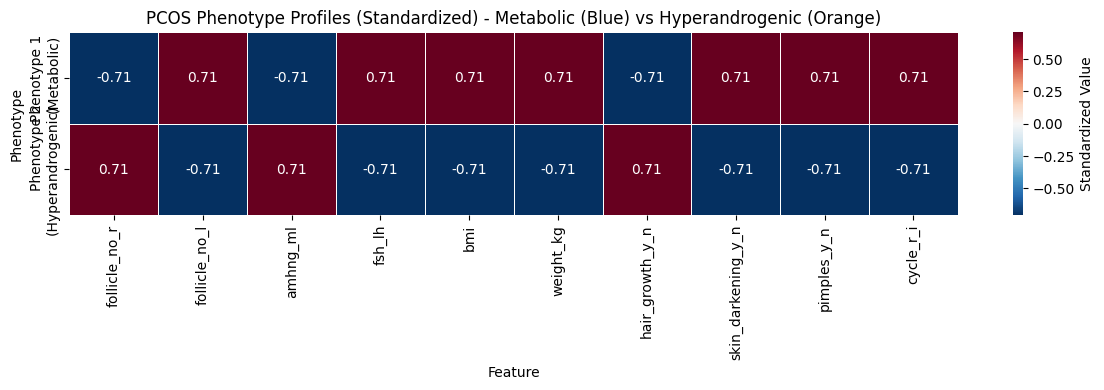

In [7]:
# Detailed phenotype comparison
print("\nDetailed PCOS Phenotype Profiles:")
print("=" * 100)

key_features = ['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'fsh_lh', 'bmi', 'weight_kg',
                'hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n', 'cycle_r_i']

for phenotype in range(optimal_k_pcos):
    phenotype_df = df_pcos[df_pcos['Cluster_PCOS'] == phenotype]
    phenotype_name = phenotype_names[phenotype]
    phenotype_color = "Blue" if phenotype_name == "Metabolic" else "Orange"
    
    print(f"\n{'PHENOTYPE ' + str(phenotype + 1) + ' - ' + phenotype_name + ' (' + phenotype_color + ')':-^100}")
    print(f"Sample size: {len(phenotype_df)} patients")
    
    for feature in key_features:
        if feature in df_pcos.columns:
            mean_val = phenotype_df[feature].mean()
            std_val = phenotype_df[feature].std()
            all_mean = df_pcos[feature].mean()
            diff_pct = ((mean_val - all_mean) / all_mean * 100) if all_mean != 0 else 0
            
            print(f"  {feature:<20}: {mean_val:>8.2f} ± {std_val:>6.2f}  ({diff_pct:>+6.1f}% vs PCOS avg)")

# Heatmap comparison
phenotype_means = []
for phenotype in range(optimal_k_pcos):
    phenotype_data = df_pcos[df_pcos['Cluster_PCOS'] == phenotype][key_features].mean()
    phenotype_means.append(phenotype_data)

phenotype_comparison = pd.DataFrame(phenotype_means, 
                                   index=[f'Phenotype {i+1}\n({phenotype_names[i]})' for i in range(optimal_k_pcos)],
                                   columns=key_features)

# Normalize for heatmap
phenotype_comparison_normalized = (phenotype_comparison - phenotype_comparison.mean()) / phenotype_comparison.std()

plt.figure(figsize=(12, 4))
sns.heatmap(phenotype_comparison_normalized, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized Value'}, linewidths=0.5)
plt.title('PCOS Phenotype Profiles (Standardized) - Metabolic (Blue) vs Hyperandrogenic (Orange)')
plt.ylabel('Phenotype')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

In [10]:
# Cycle irregularity rate by phenotype
print("Cycle Irregularity by Phenotype:")
print("-" * 45)
for phenotype in range(optimal_k_pcos):
    phenotype_df = df_pcos[df_pcos["Cluster_PCOS"] == phenotype]
    pct = phenotype_df["cycle_r_i"].mean() * 100
    n   = len(phenotype_df)
    name = phenotype_names[phenotype]
    print(f"  Phenotype {phenotype + 1} ({name}, n={n}): {pct:.1f}% irregular")

Cycle Irregularity by Phenotype:
---------------------------------------------
  Phenotype 1 (Metabolic, n=59): 62.7% irregular
  Phenotype 2 (Hyperandrogenic, n=118): 48.3% irregular


## Key Insights

**Full Dataset**: Identified 3 major population clusters (likely based on follicle/hormone patterns)
**PCOS Group**: Identified 2 distinct phenotypes within PCOS patients